<a href="https://colab.research.google.com/github/irinavalenzuela/Learning-Applied-Machine-Learning-with-Python/blob/main/scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_boston

In [1]:
import pandas as pd

#load data as boston from a CSV file
boston = pd.read_csv("boston.csv")

In [ ]:
boston.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [2]:
print(boston.head(5))

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [3]:
#Prepare data for sklearn: separate the features (X) and target (y) variables
X = boston.drop("PRICE", axis=1) #features (all variables except Price)
y = boston["PRICE"] #Target

In [ ]:
#scikit-learn has many models

#Model: K-Nearet Neighor
from sklearn.neighbors import KNeighborsRegressor

mod = KNeighborsRegressor() #This is our model
mod.fit(X,y) #Our model (mod=KN) will learn from our data (X,y)
mod.predict(X) #Then, it will make prediction

In [ ]:
#Another model: linear regression
from sklearn.linear_model import LinearRegression

#Even though linear regression model is different from KNN, we can still use the same syntaxis
#Just now we say that our model is LinearRegression

mod = LinearRegression() #This is our model
mod.fit(X,y) #Our model (mod=linear reg) will learn from our data (X,y)
mod.predict(X) #Then, it will make prediction

#We will have different prediction, because the model is different, but the API is the same

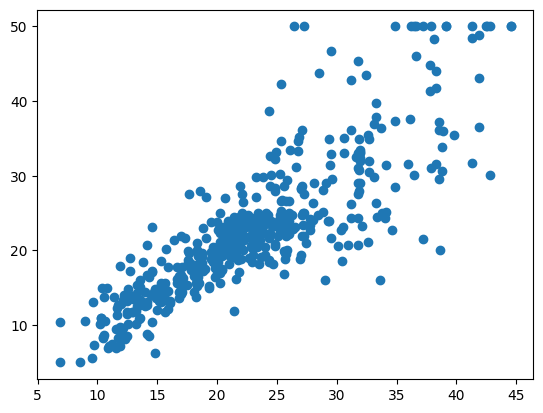

In [6]:
#Plot Model KNN
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pylab as plt

mod = KNeighborsRegressor().fit(X,y)
pred = mod.predict(X)

#y=original values and pred=predicted values

#Lets plot them
plt.scatter(pred, y)

In [ ]:
#Re-define what a model is (Pre-processing before running the model)

#For example, one variable is in thousands and another in units
#Therefore, we need to do some scaling to X variables.
#Since the scaling may lead to different predictions, we can think that all these pre-processing is part of the model
#This is because this scaling also needs to learn from the data to scale it and normalize it

from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pylab as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline #to change pre-processing steps

mod = KNeighborsRegressor().fit(X,y)

#Start a new pipeline object (pair a name with a step)
pipe = Pipeline ([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())

])



In [ ]:
pipe.fit(X,y) #this pipeline train and fit itself
pred = pipe.predict(X)


#Lets plot predicted and original values
plt.scatter(pred, y)


In [ ]:
#Issues with prediction

#We were learning in the same data that we were judging on.
#That is, we are using the same data we want to predict to make the predictions


#let see this issue but choosing one 1 nearest neighbor
pipe = Pipeline ([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=1))

])

pipe.fit(X,y) #this pipeline train and fit itself
pred = pipe.predict(X)

#We can see here that the prediction is perfect because the model is using the same data that is trying to predict
plt.scatter(pred, y)

#We want to predict data that we havent see before


In [ ]:
#Grid Search

#We want our model also choose the best nro of KNN

#GridSearchCV object: we will give a pipeline and the nr of grid, and internally will perform Cross-validation (CV)


#load data as boston from a CSV file
import pandas as pd
boston = pd.read_csv("boston.csv")

#sklearn library
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import matplotlib.pylab as plt

#Prepare data for sklearn: separate the features (X) and target (y) variables
X = boston.drop("PRICE", axis=1) #features (all variables except Price)
y = boston["PRICE"] #Target

#Start a new pipeline object (pair a name with a step)
pipe = Pipeline ([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())

#New gridsearch object
GridSearchCV(estimator=pipe,
             param_grid=)